### Summary of Analysis Steps

This notebook provides a comprehensive analysis of the healthcare risk dataset, following these key steps:

1.  **Data Loading and Initial Inspection**: The process began by uploading and loading the `healthcare_risk_analysis_dataset.xlsx` file into a pandas DataFrame. We then used `df.head()` and `df.info()` to get an initial understanding of the data structure, column types, and identify missing values.

2.  **Data Cleaning: Handling Missing Values**: We addressed missing values in the dataset:
    *   **Numerical columns** (`BMI`, `Cholesterol_Level`, `Glucose_Level`, `Sleep_Hours`) were imputed using their respective **medians** to maintain robustness against outliers.
    *   **Categorical columns** (`Alcohol_Consumption`, `Diagnosed_Condition`) were imputed with the placeholder value **'Unknown'**.

3.  **Data Normalization: Min-Max Scaling**: The `Age` column was normalized using Min-Max scaling to a range between 0 and 1. This step is crucial for many machine learning algorithms that are sensitive to feature scales.

4.  **Exploratory Data Analysis (EDA)**:
    *   **Distributions**: Visualized the distributions of `Age` and `BMI` using histograms to understand their spread.
    *   **Relationships**: Explored the relationship between `Age` and `BMI` using a scatter plot.
    *   **Lifestyle Patterns**: Analyzed the distributions of various lifestyle factors (`Smoking_Status`, `Alcohol_Consumption`, `Physical_Activity`, `Diet_Type`, `Sleep_Hours`, `Stress_Level`) to understand common trends.
    *   **Lifestyle vs. Risk Level**: Investigated how lifestyle patterns correlate with `Risk_Level` using count plots for categorical variables and box plots for numerical ones.

5.  **Statistical Hypothesis Testing: ANOVA**: Performed one-way Analysis of Variance (ANOVA) to test for statistically significant differences in means of several numerical health indicators (`Age`, `BMI`, `Systolic_BP`, `Diastolic_BP`, `Cholesterol_Level`, `Glucose_Level`, `Sleep_Hours`, `Stress_Level`) across the `Low`, `Moderate`, and `High` `Risk_Level` groups. We also discussed the important distinction between correlation and causation.

6.  **Visualization of Significant Health Indicators**: Generated box plots for the health indicators that showed statistically significant differences in the ANOVA test (Age, BMI, Systolic_BP, Diastolic_BP, Cholesterol_Level, Glucose_Level) to visually confirm the identified trends.

7.  **SQL-like Queries for Patient Grouping and Actionable Insights**: Used pandas' grouping capabilities to extract key insights:
    *   Calculated the **number of patients** in each `Risk_Level` category.
    *   Computed the **average values** of key health indicators for each `Risk_Level`.
    *   Identified the **top diagnosed conditions** within each `Risk_Level` (excluding 'Unknown' conditions) to understand prevalent health issues in each group.

8.  **Health Reports by Risk Level**: Consolidated the average health indicators and top diagnosed conditions into structured text-based health reports for each `Risk_Level` (Low, Moderate, High).

9.  **Visual Dashboard: Key Risk Insights**: Created a comprehensive visual dashboard displaying patient counts by risk level, and the distributions of Age, BMI, and Cholesterol Level by risk level, offering a quick and insightful overview of the main findings.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

print("Please upload your CSV file:")
uploaded = files.upload()


Please upload your CSV file:


Saving healthcare_risk_analysis_dataset.xlsx to healthcare_risk_analysis_dataset.xlsx


In [2]:
# Assuming only one file is uploaded, get the filename
for fn in uploaded.keys():
  file_name = fn

# Read the Excel file into a pandas DataFrame
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

df.head()

,Patient_ID,Patient_Name,Age,Gender,Height_cm,Weight_kg,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity,...,Family_History,Systolic_BP,Diastolic_BP,Cholesterol_Level,Glucose_Level,Sleep_Hours,Stress_Level,Diagnosed_Condition,Risk_Level,Last_Visit_Date
0,1,Jose Diaz,69,Other,156.9,76.8,31.2,Never,Occasional,Low,...,Yes,137,97,203.0,104.0,6.1,6,Hypertension,High,2024-04-13
1,2,Sherri Armstrong,66,Other,158.8,35.4,14.1,Never,Occasional,Low,...,No,142,84,199.0,71.0,9.2,4,NaN,Moderate,2025-10-04
2,3,Tina Sawyer,81,Male,179.3,70.4,21.9,Former,Occasional,Moderate,...,Yes,128,107,151.0,129.0,8.2,8,Heart Disease,Moderate,2024-04-26
3,4,Charles Christensen,64,Male,157.0,66.2,26.9,Former,Occasional,Low,...,Yes,115,92,195.0,83.0,6.5,4,NaN,Moderate,2025-01-26
4,5,Alex Anderson,71,Male,146.2,56.3,26.4,Never,Occasional,Low,...,No,136,90,238.0,74.0,7.8,5,NaN,Moderate,2023-10-04


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Patient_ID           6000 non-null   int64         
 1   Patient_Name         6000 non-null   object        
 2   Age                  6000 non-null   int64         
 3   Gender               6000 non-null   object        
 4   Height_cm            6000 non-null   float64       
 5   Weight_kg            6000 non-null   float64       
 6   BMI                  5940 non-null   float64       
 7   Smoking_Status       6000 non-null   object        
 8   Alcohol_Consumption  4176 non-null   object        
 9   Physical_Activity    6000 non-null   object        
 10  Diet_Type            6000 non-null   object        
 11  Family_History       6000 non-null   object        
 12  Systolic_BP          6000 non-null   int64         
 13  Diastolic_BP         6000 non-nul

### Data Cleaning: Handling Missing Values

Based on `df.info()`, several columns have missing values. We will impute them as follows:
- **Numerical columns** (`BMI`, `Cholesterol_Level`, `Glucose_Level`, `Sleep_Hours`): Impute with the **median** to be robust to outliers.
- **Categorical columns** (`Alcohol_Consumption`, `Diagnosed_Condition`): Impute with a placeholder value, 'Unknown'.

In [6]:
# Imputing numerical missing values with the median
for col in ['BMI', 'Cholesterol_Level', 'Glucose_Level', 'Sleep_Hours']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled missing values in '{col}' with median: {median_val}")

# Imputing categorical missing values with 'Unknown'
for col in ['Alcohol_Consumption', 'Diagnosed_Condition']:
    if df[col].isnull().any():
        df[col] = df[col].fillna('Unknown')
        print(f"Filled missing values in '{col}' with 'Unknown'")

print("\nDataFrame info after handling missing values:")
df.info()


DataFrame info after handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Patient_ID           6000 non-null   int64         
 1   Patient_Name         6000 non-null   object        
 2   Age                  6000 non-null   int64         
 3   Gender               6000 non-null   object        
 4   Height_cm            6000 non-null   float64       
 5   Weight_kg            6000 non-null   float64       
 6   BMI                  6000 non-null   float64       
 7   Smoking_Status       6000 non-null   object        
 8   Alcohol_Consumption  6000 non-null   object        
 9   Physical_Activity    6000 non-null   object        
 10  Diet_Type            6000 non-null   object        
 11  Family_History       6000 non-null   object        
 12  Systolic_BP          6000 non-null   int64 

### Data Normalization: Min-Max Scaling

Normalization scales numerical features to a specific range (e.g., 0 to 1). This is often important for machine learning algorithms that are sensitive to the magnitude of feature values. Here, we'll apply Min-Max scaling to the `Age` column as an example:

$X_{normalized} = (X - X_{min}) / (X_{max} - X_{min})$

In [5]:
# Apply Min-Max scaling to the 'Age' column
min_age = df['Age'].min()
max_age = df['Age'].max()
df['Age_normalized'] = (df['Age'] - min_age) / (max_age - min_age)

print("\nFirst 5 rows of DataFrame with 'Age_normalized' column:")
display(df[['Age', 'Age_normalized']].head())


First 5 rows of DataFrame with 'Age_normalized' column:


,Age,Age_normalized
0,69,0.772727
1,66,0.727273
2,81,0.954545
3,64,0.696970
4,71,0.803030


### Exploratory Data Analysis (EDA): Age, BMI, and Lifestyle Patterns

#### 1. Age and BMI Distributions

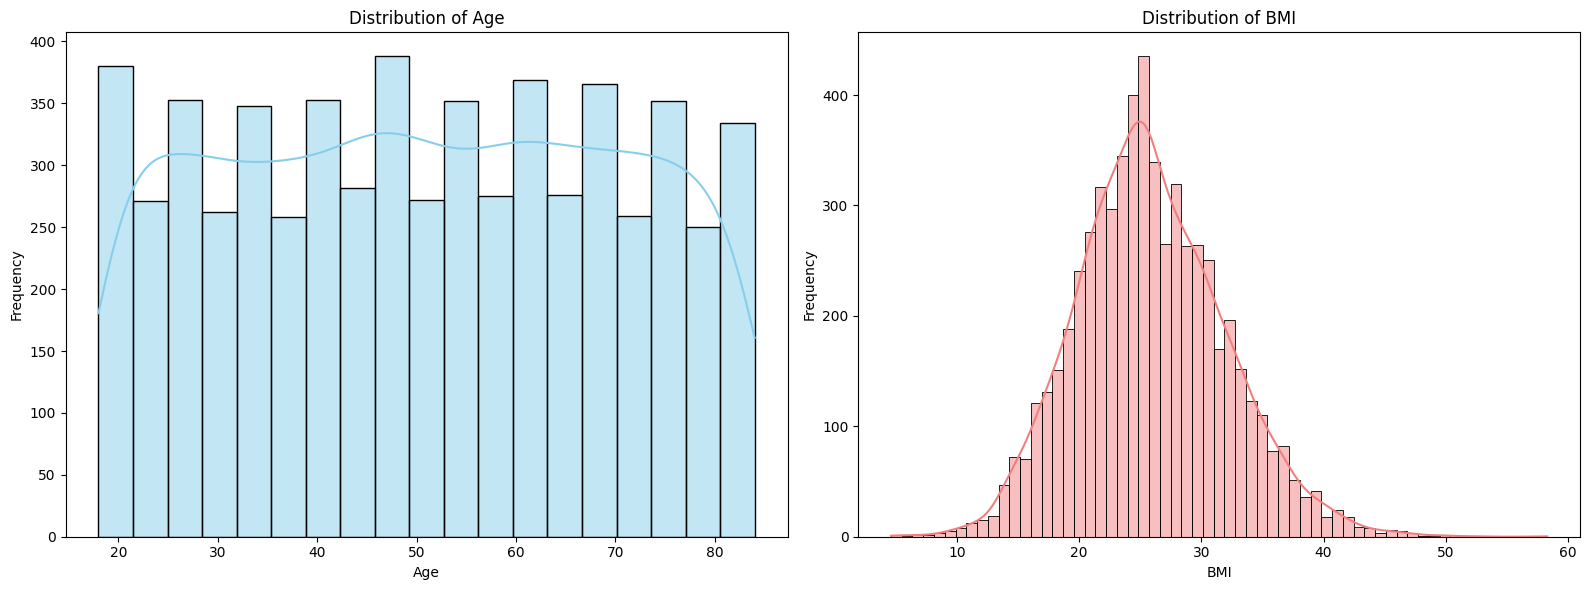

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of Age
sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Distribution of BMI
sns.histplot(df['BMI'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of BMI')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#### 2. Relationship Between Age and BMI

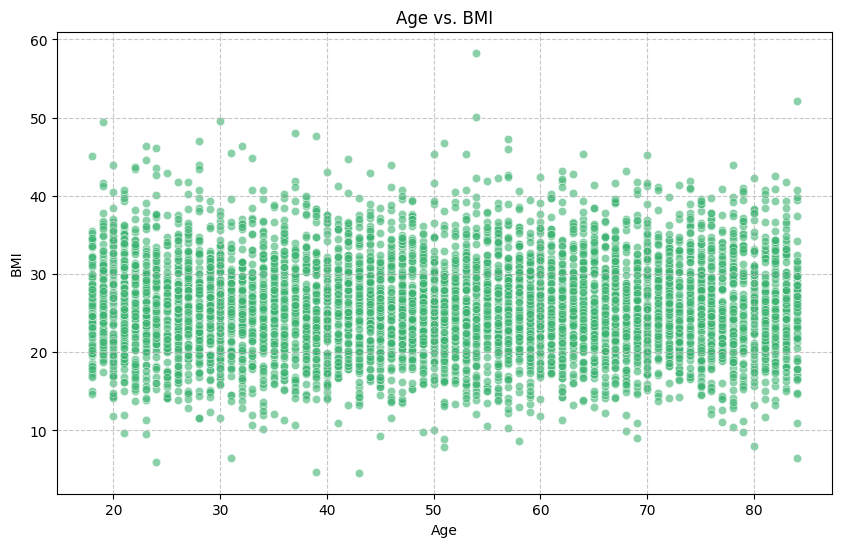

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='BMI', data=df, alpha=0.6, color='mediumseagreen')
plt.title('Age vs. BMI')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### 3. Lifestyle Patterns Analysis

Let's examine the distribution of various lifestyle factors and their potential impact on 'Risk_Level'.

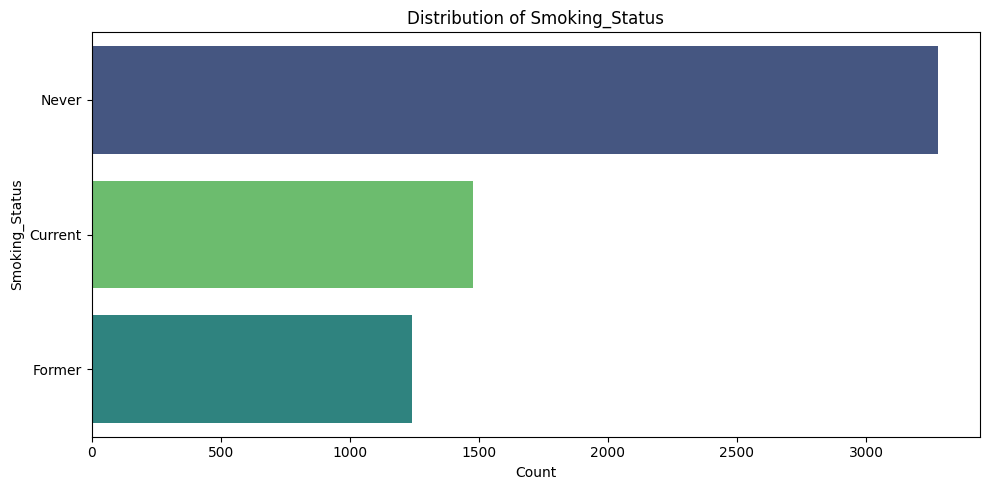

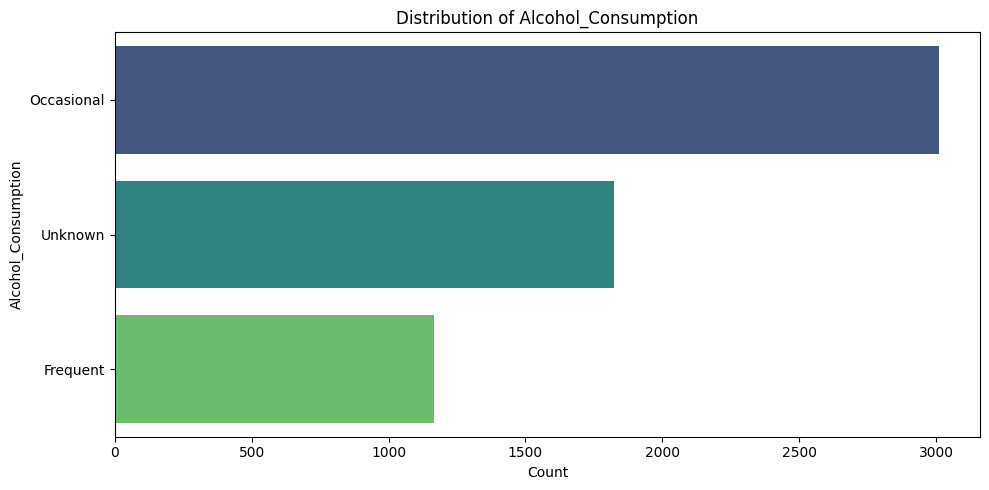

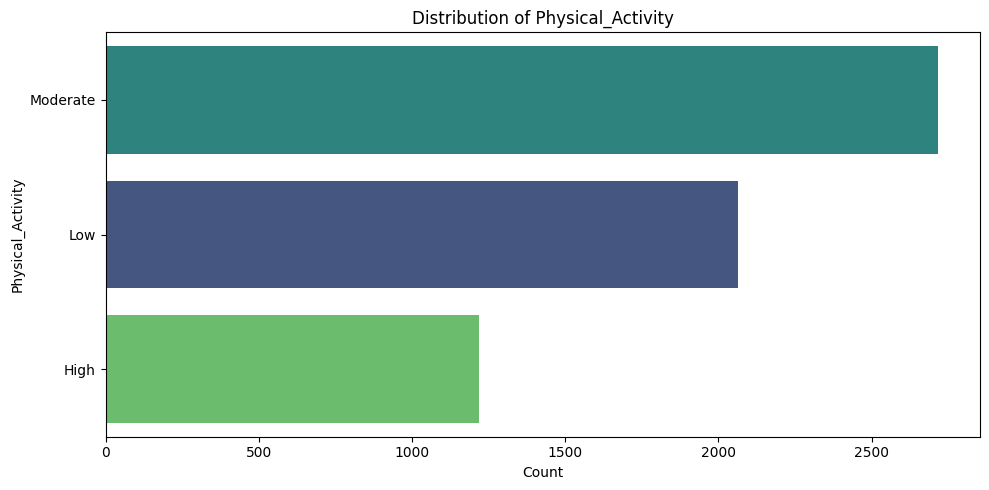

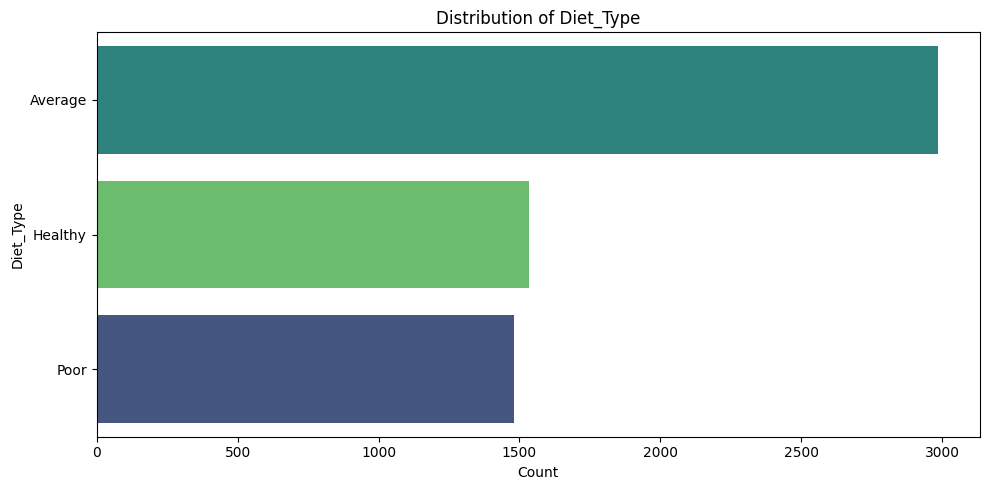

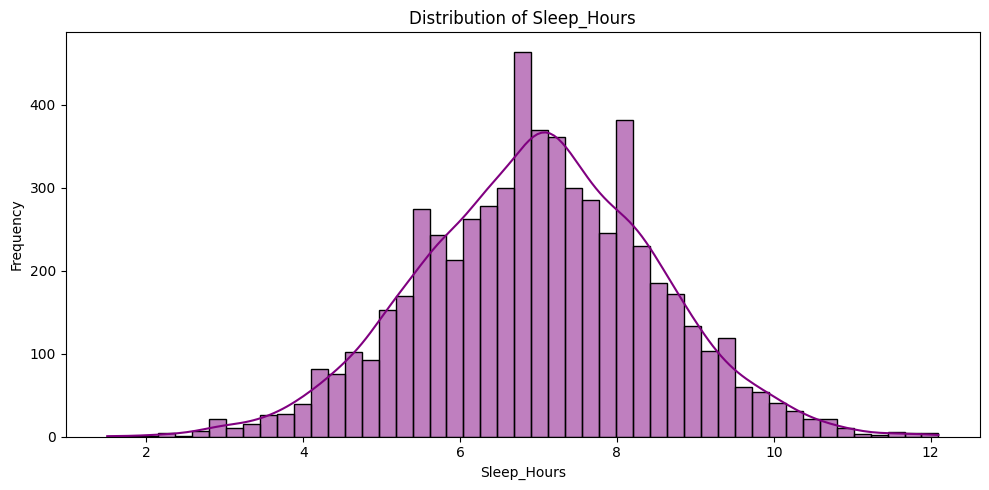

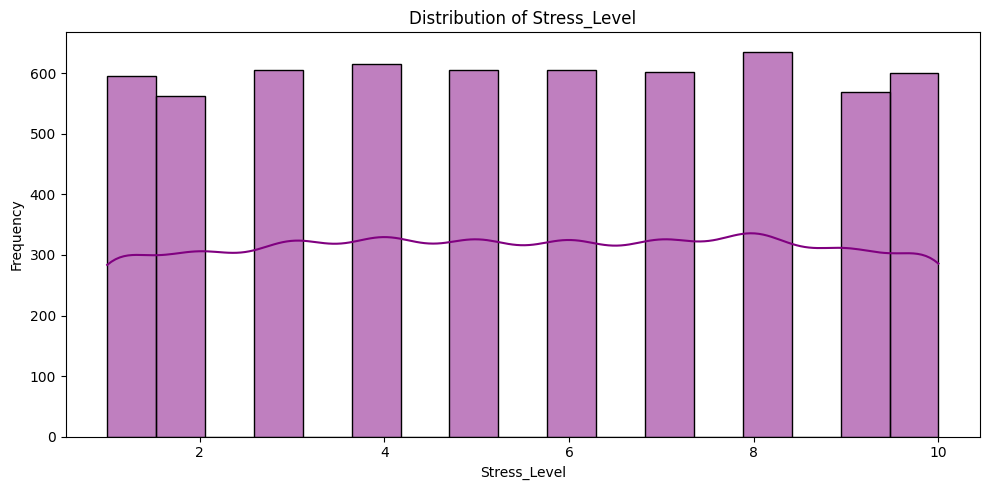

In [11]:
lifestyle_cols = ['Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity', 'Diet_Type', 'Sleep_Hours', 'Stress_Level']

for col in lifestyle_cols:
    plt.figure(figsize=(10, 5))
    if col in ['Sleep_Hours', 'Stress_Level']:
        sns.histplot(df[col], kde=True, color='purple')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    else:
        # Set 'y' as hue to suppress FutureWarning, then set legend=False as no meaningful hue is intended here.
        sns.countplot(y=col, data=df, palette='viridis', order=df[col].value_counts().index, hue=df[col], legend=False)
        plt.title(f'Distribution of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
    plt.tight_layout()
    plt.show()

#### 4. Lifestyle Patterns vs. Risk Level

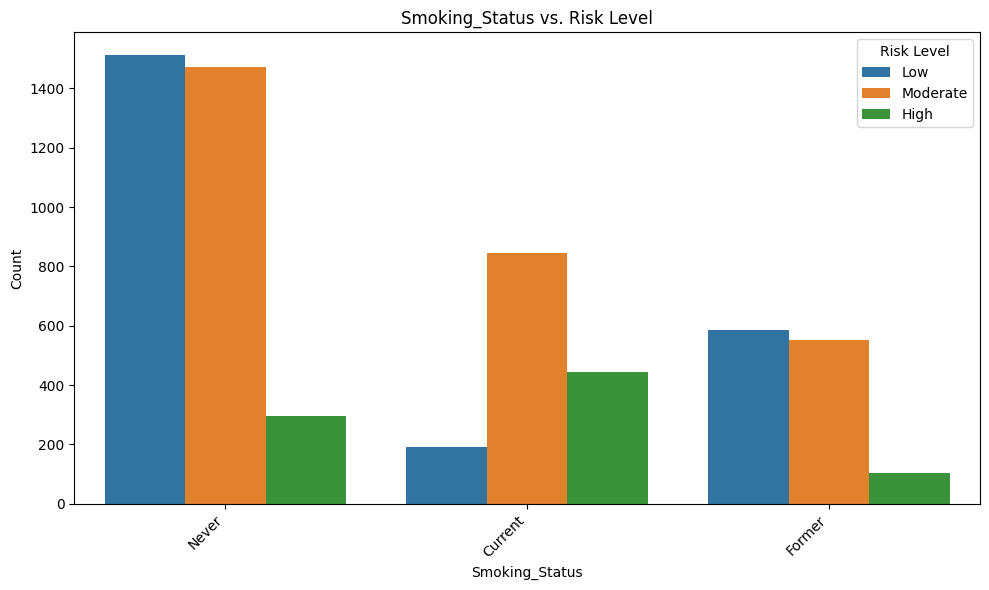

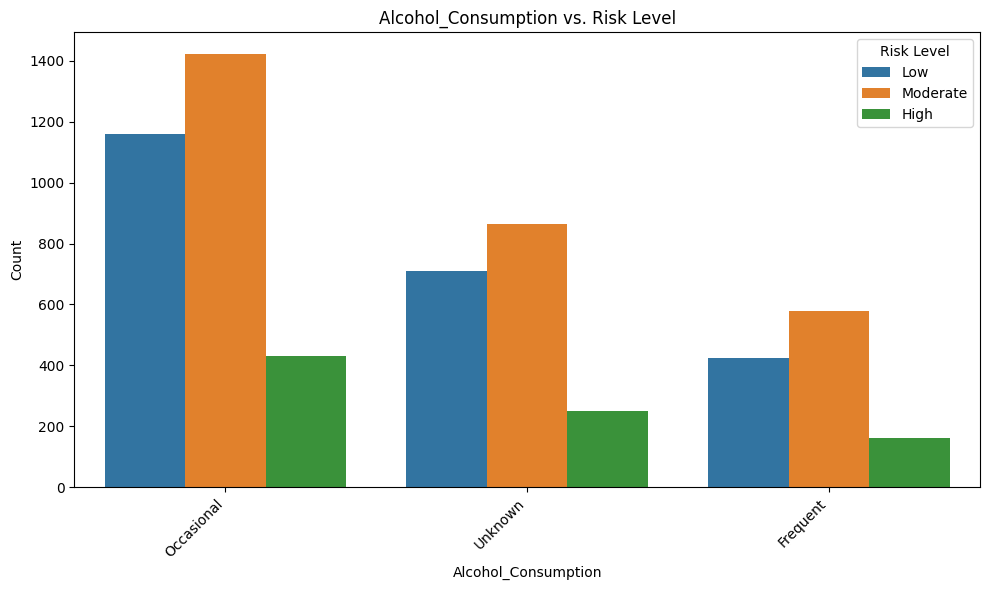

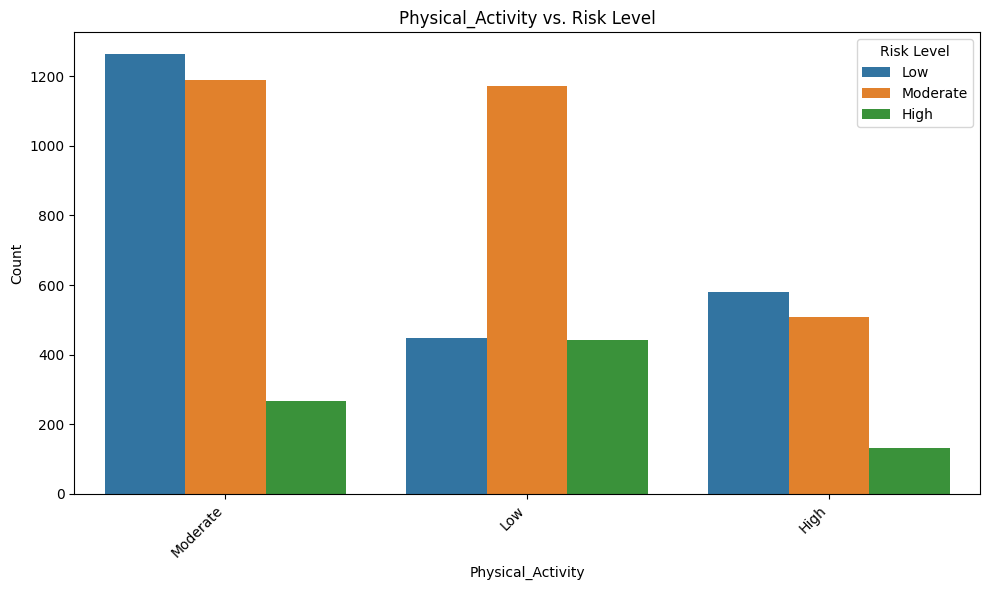

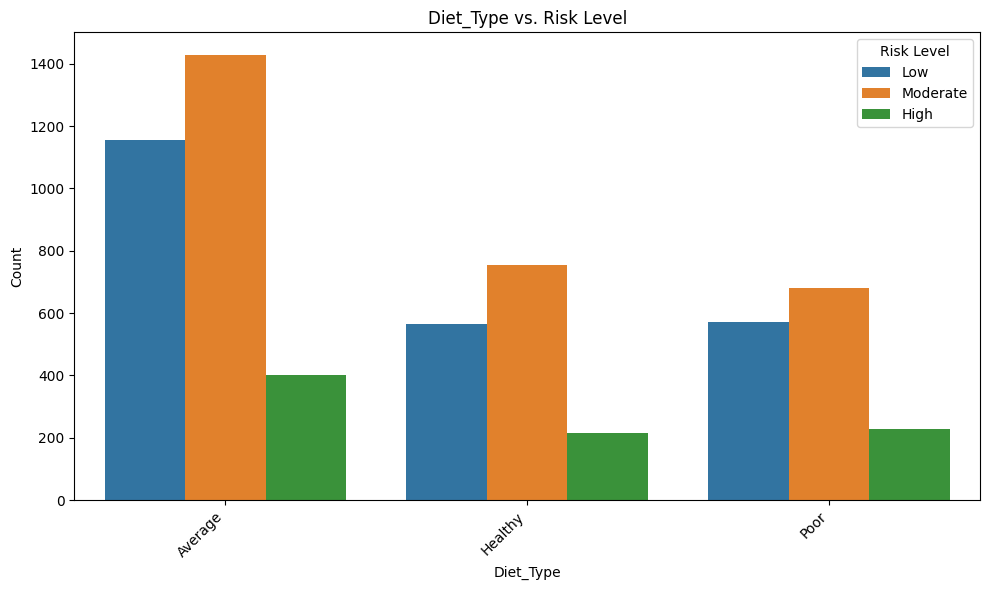

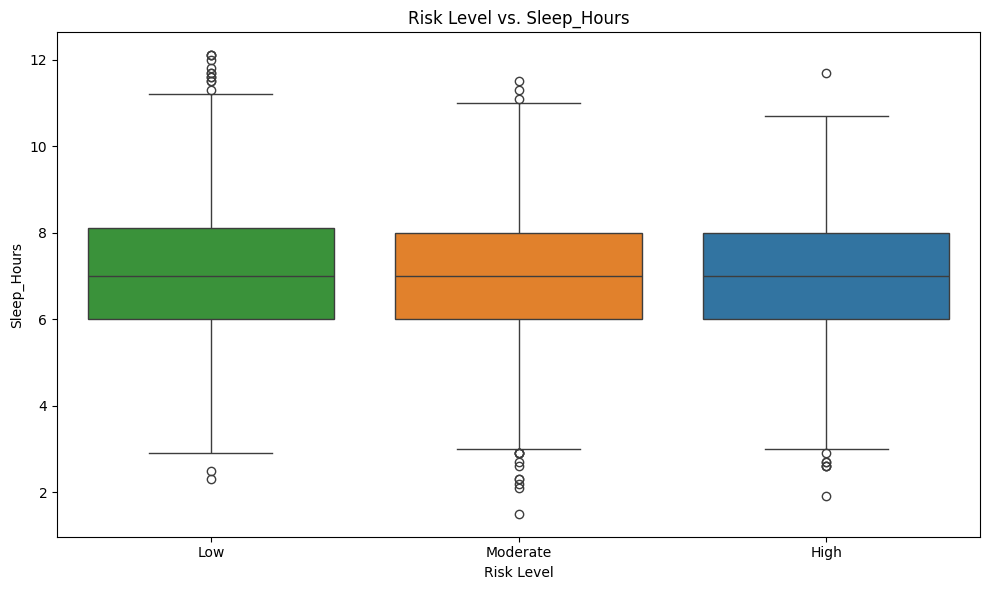

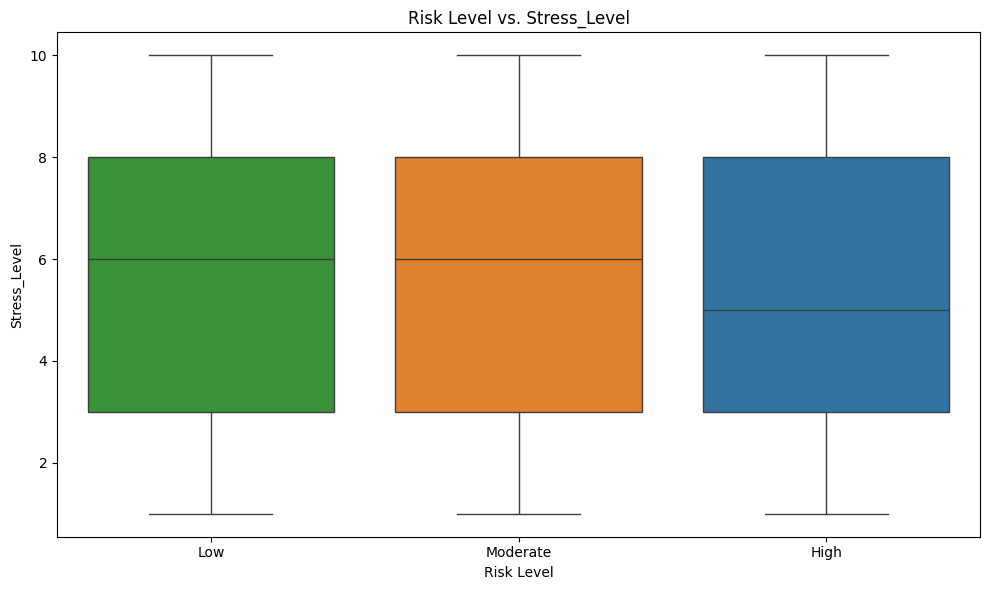

In [12]:
risk_order = ['Low', 'Moderate', 'High']

for col in ['Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity', 'Diet_Type']:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, hue='Risk_Level', palette='tab10', order=df[col].value_counts().index, hue_order=risk_order)
    plt.title(f'{col} vs. Risk Level')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Risk Level')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

for col in ['Sleep_Hours', 'Stress_Level']:
    plt.figure(figsize=(10, 6))
    # Set 'x' as hue to suppress FutureWarning, then set legend=False if no meaningful hue is intended.
    sns.boxplot(data=df, x='Risk_Level', y=col, palette='tab10', order=risk_order, hue='Risk_Level', legend=False)
    plt.title(f'Risk Level vs. {col}')
    plt.xlabel('Risk Level')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Statistical Hypothesis Testing: ANOVA

We will use Analysis of Variance (ANOVA) to determine if there are statistically significant differences between the means of three or more independent (unrelated) groups. In our case, we'll test if the means of various numerical health indicators differ significantly across the 'Low', 'Moderate', and 'High' `Risk_Level` groups.

In [13]:
from scipy import stats

numerical_cols_for_anova = [
    'Age', 'BMI', 'Systolic_BP', 'Diastolic_BP',
    'Cholesterol_Level', 'Glucose_Level', 'Sleep_Hours', 'Stress_Level'
]

risk_levels = df['Risk_Level'].unique()

print("ANOVA Test Results for Numerical Features vs. Risk Level:")
print("----------------------------------------------------------")

for col in numerical_cols_for_anova:
    # Create a list of numerical values for each risk level
    groups = [df[col][df['Risk_Level'] == level] for level in risk_levels]

    # Perform one-way ANOVA test
    f_statistic, p_value = stats.f_oneway(*groups)

    print(f"\nFeature: {col}")
    print(f"  F-statistic: {f_statistic:.2f}")
    print(f"  P-value: {p_value:.3f}")

    alpha = 0.05 # Significance level
    if p_value < alpha:
        print(f"  Conclusion: Reject the null hypothesis. There is a statistically significant difference in {col} across different Risk Levels.")
    else:
        print(f"  Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference in {col} across different Risk Levels.")

ANOVA Test Results for Numerical Features vs. Risk Level:
----------------------------------------------------------

Feature: Age
  F-statistic: 552.27
  P-value: 0.000
  Conclusion: Reject the null hypothesis. There is a statistically significant difference in Age across different Risk Levels.

Feature: BMI
  F-statistic: 463.13
  P-value: 0.000
  Conclusion: Reject the null hypothesis. There is a statistically significant difference in BMI across different Risk Levels.

Feature: Systolic_BP
  F-statistic: 38.22
  P-value: 0.000
  Conclusion: Reject the null hypothesis. There is a statistically significant difference in Systolic_BP across different Risk Levels.

Feature: Diastolic_BP
  F-statistic: 10.93
  P-value: 0.000
  Conclusion: Reject the null hypothesis. There is a statistically significant difference in Diastolic_BP across different Risk Levels.

Feature: Cholesterol_Level
  F-statistic: 359.64
  P-value: 0.000
  Conclusion: Reject the null hypothesis. There is a statistical

#### Interpreting ANOVA Results

*   **F-statistic**: A larger F-statistic indicates more variation between group means relative to the variation within groups.
*   **P-value**: This is the probability of observing an F-statistic as extreme as, or more extreme than, the one calculated if the null hypothesis were true (i.e., if there were no differences between group means).

If the **P-value is less than our significance level (commonly 0.05)**, we **reject the null hypothesis**. This suggests that there is a statistically significant difference in the mean of that feature across at least one pair of `Risk_Level` groups. However, ANOVA does not tell us *which* specific groups differ from each other; further post-hoc tests would be needed for that.

### Correlation vs. Causation: Discussion

It's important to remember that **correlation does not imply causation**. Our ANOVA test results show statistically significant differences in some numerical features (`Age`, `BMI`, `Systolic_BP`, `Diastolic_BP`, `Cholesterol_Level`, `Glucose_Level`) across different `Risk_Level` groups.

This means that there is a relationship or association between these features and the assigned `Risk_Level`. For instance, if higher Age is associated with a higher Risk Level, we can say they are correlated.

However, this test alone does not tell us that a change in `Age` *causes* a change in `Risk_Level`. There could be many reasons for the observed correlation:

1.  **Direct Causation**: One variable directly influences the other (e.g., perhaps high cholesterol directly contributes to a higher risk level).
2.  **Reverse Causation**: The `Risk_Level` might influence the feature (less likely in this context, but a general consideration).
3.  **Common Cause (Confounding Variable)**: An unmeasured third variable might be influencing both the feature and the `Risk_Level`. For example, a poor diet might lead to both higher `BMI` and higher `Risk_Level`.
4.  **Coincidence**: The relationship might be purely by chance.

To establish causation, more rigorous study designs are required, such as randomized controlled trials, or more advanced statistical modeling that accounts for potential confounding factors. Our current analysis identifies strong associations, which are valuable for understanding the dataset and identifying areas for further investigation, but we must be cautious not to draw causal conclusions solely from these statistical tests.

### Visualization of Health Indicators by Risk Level

Following our ANOVA results, we'll now visualize the distribution of health indicators that showed statistically significant differences across 'Low', 'Moderate', and 'High' `Risk_Level` groups. Box plots are excellent for comparing the distribution of a numerical variable across different categories.

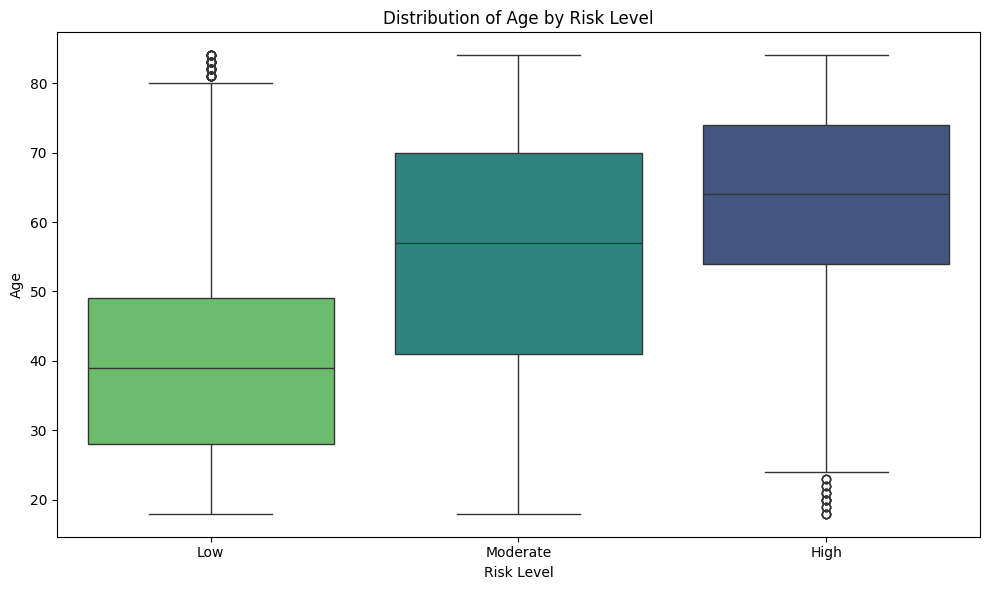

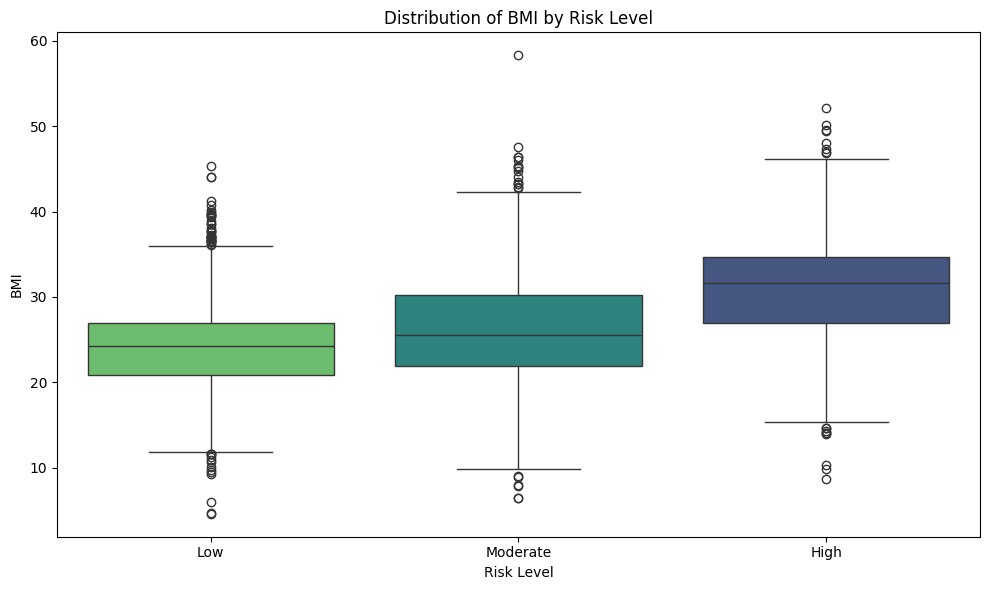

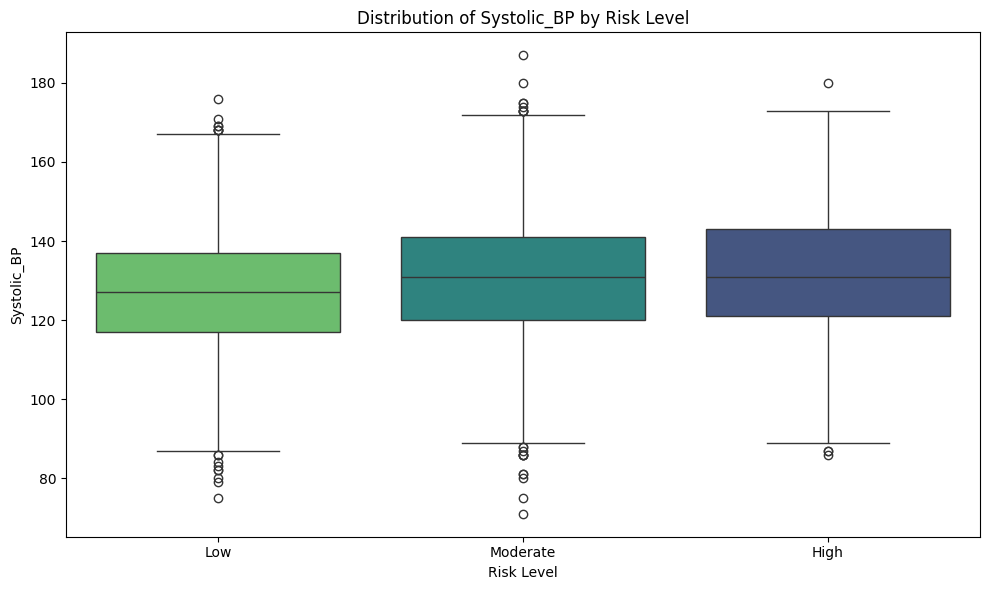

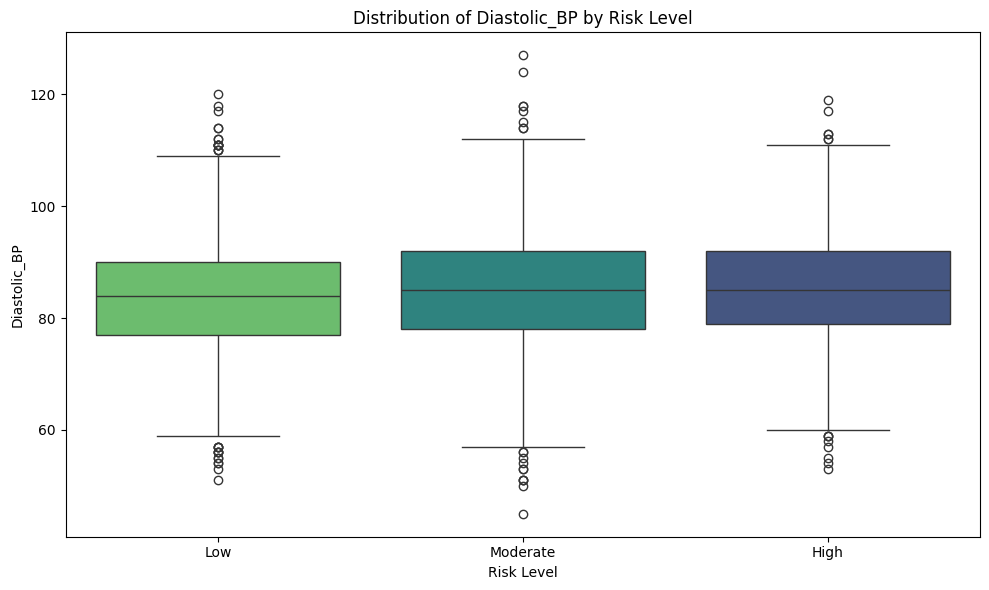

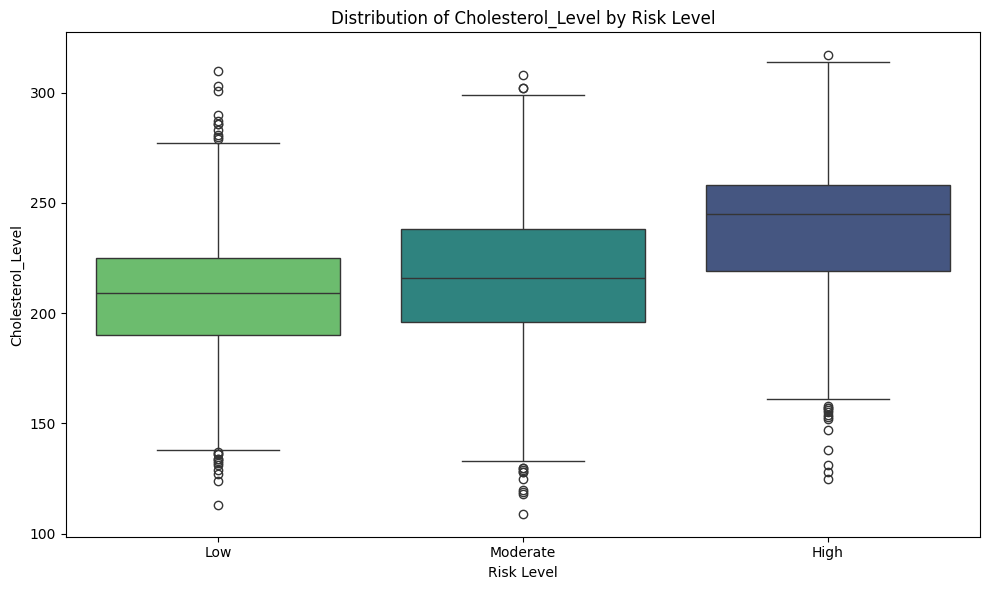

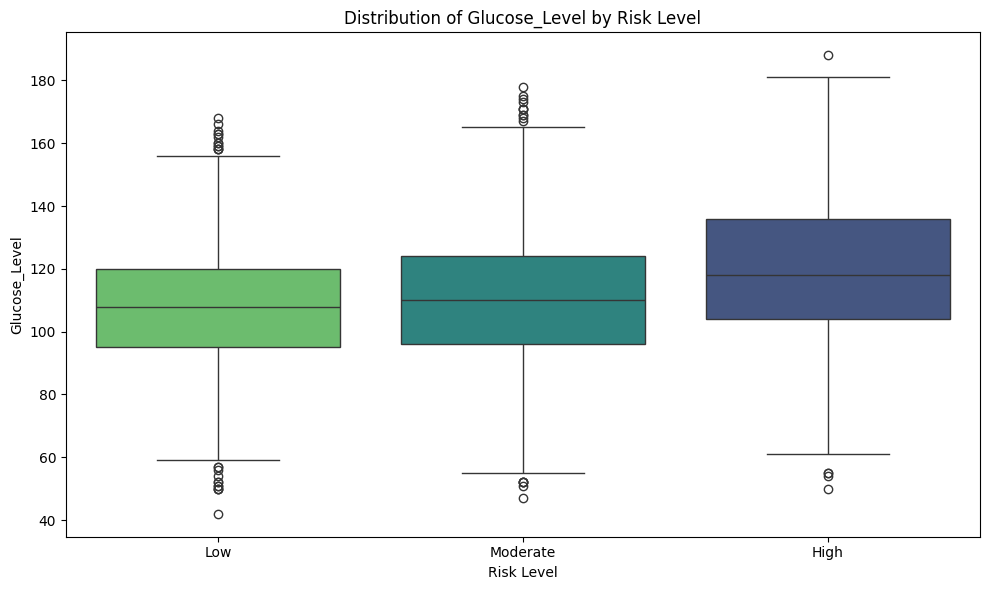

In [15]:
numerical_cols_significant = [
    'Age', 'BMI', 'Systolic_BP', 'Diastolic_BP',
    'Cholesterol_Level', 'Glucose_Level'
]
risk_order = ['Low', 'Moderate', 'High']

for col in numerical_cols_significant:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Risk_Level', y=col, hue='Risk_Level', palette='viridis', order=risk_order, legend=False)
    plt.title(f'Distribution of {col} by Risk Level')
    plt.xlabel('Risk Level')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### SQL-like Queries for Patient Grouping and Actionable Insights

We'll use pandas to perform operations similar to SQL queries to group our patient data and extract valuable insights. This will help us understand the characteristics of different patient segments, especially in relation to their `Risk_Level` and `Diagnosed_Condition`.

#### 1. Patient Count by Risk Level

First, let's see how many patients fall into each `Risk_Level` category.

,Risk_Level,Patient_Count
0,High,843
1,Low,2291
2,Moderate,2866


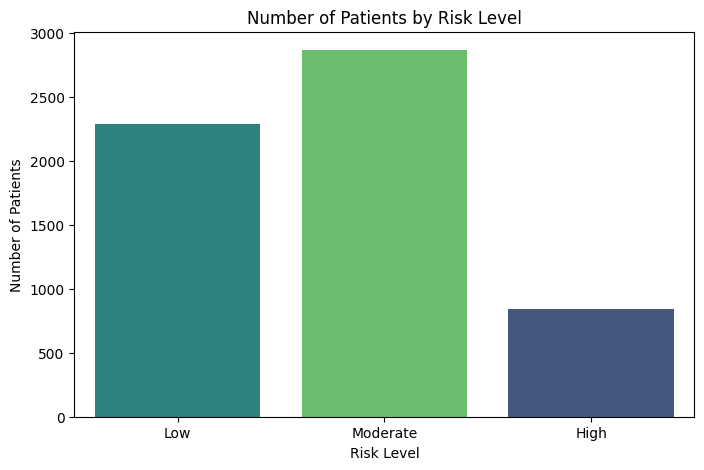

In [19]:
patient_counts_by_risk = df.groupby('Risk_Level').size().reset_index(name='Patient_Count')
display(patient_counts_by_risk)

plt.figure(figsize=(8, 5))
sns.barplot(x='Risk_Level', y='Patient_Count', data=patient_counts_by_risk, order=['Low', 'Moderate', 'High'], palette='viridis', hue='Risk_Level', legend=False)
plt.title('Number of Patients by Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Number of Patients')
plt.show()

#### 2. Average Health Indicators by Risk Level

Next, let's calculate the average of key numerical health indicators for each `Risk_Level`.

In [21]:
avg_health_by_risk = df.groupby('Risk_Level')[numerical_cols_significant + ['Sleep_Hours', 'Stress_Level']].mean().reset_index()
display(avg_health_by_risk)

,Risk_Level,Age,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Level,Glucose_Level,Sleep_Hours,Stress_Level
0,High,61.417556,30.781613,131.352313,84.960854,237.956109,118.569395,6.977580,5.366548
1,Low,41.487997,23.851637,127.085116,83.746399,206.935836,106.827586,7.026975,5.506766
2,Moderate,54.981158,26.011026,130.418004,85.026169,216.844033,110.056176,6.973133,5.569086


#### 3. Top Diagnosed Conditions within Each Risk Level

Understanding the most common diagnosed conditions within each risk group can provide actionable insights for targeted interventions.

,Risk_Level,Diagnosed_Condition,Count
0,High,Diabetes,177
1,High,Hypertension,168
2,High,Asthma,92
3,High,Heart Disease,90
4,Low,Diabetes,481
5,Low,Hypertension,470
6,Low,Asthma,213
7,Low,Heart Disease,209
8,Moderate,Hypertension,602
9,Moderate,Diabetes,541


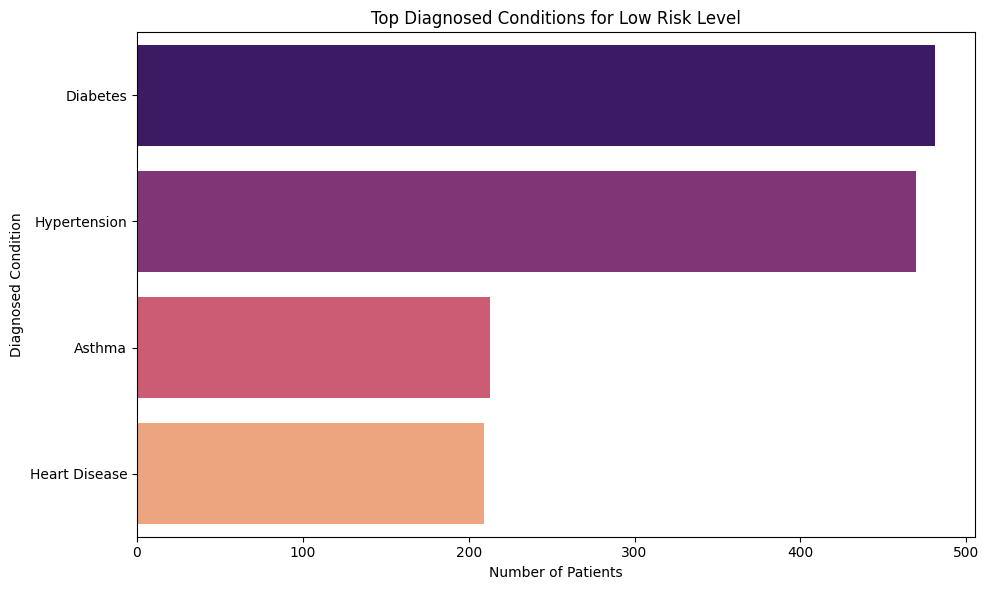

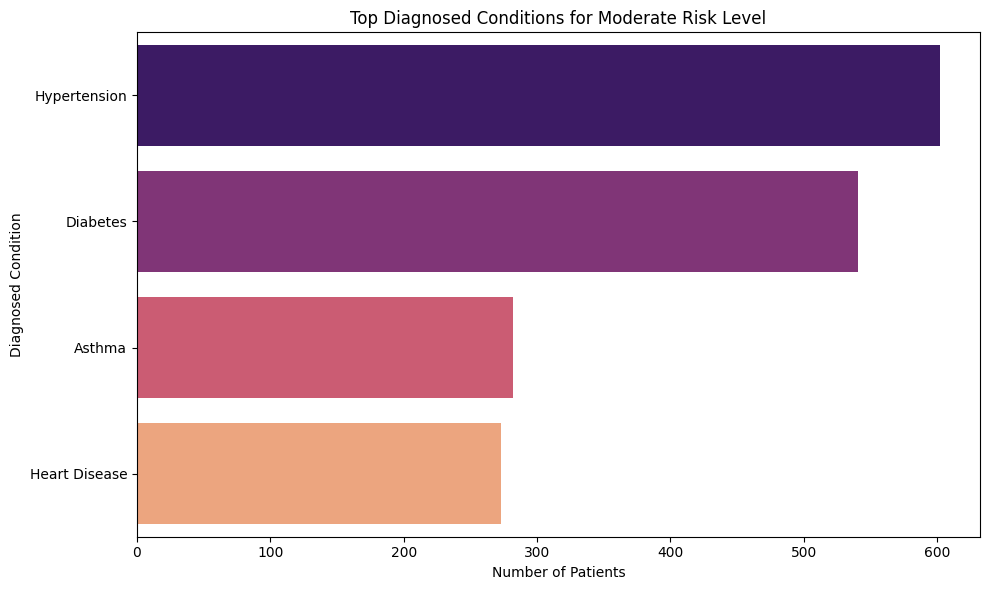

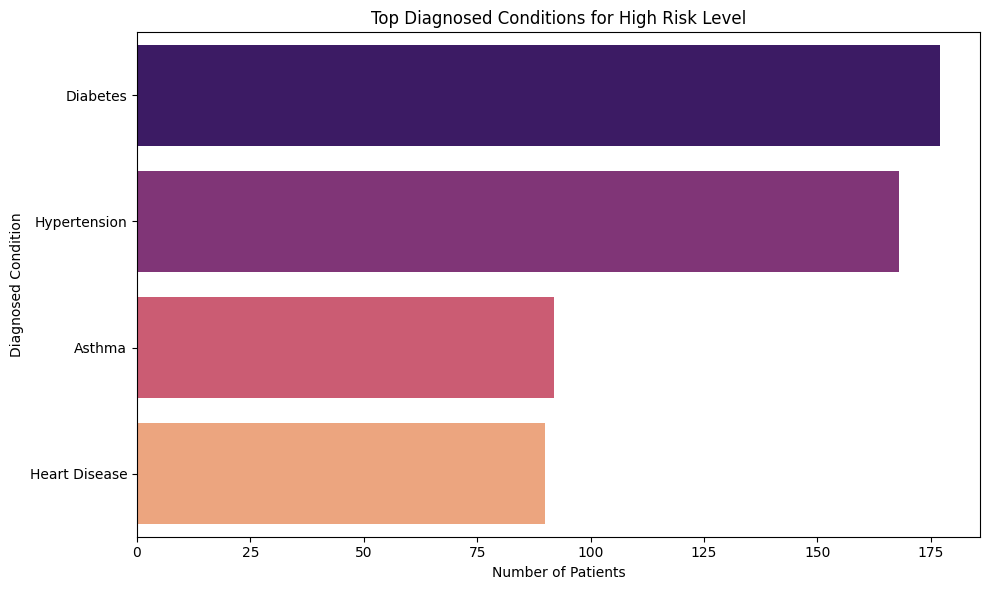

In [22]:
top_conditions_by_risk = df.groupby('Risk_Level')['Diagnosed_Condition'].value_counts().reset_index(name='Count')

# Filter out 'Unknown' condition for better insight into known conditions
top_conditions_by_risk = top_conditions_by_risk[top_conditions_by_risk['Diagnosed_Condition'] != 'Unknown']

# Get top N conditions for each risk level
def get_top_n(group, n=5):
    return group.nlargest(n, 'Count')

top_conditions_by_risk_filtered = top_conditions_by_risk.groupby('Risk_Level').apply(get_top_n, include_groups=False).reset_index()
top_conditions_by_risk_filtered.drop(columns='level_1', inplace=True)

display(top_conditions_by_risk_filtered)

# Visualize top conditions for each risk level
risk_levels_ordered = ['Low', 'Moderate', 'High']
for risk in risk_levels_ordered:
    plt.figure(figsize=(10, 6))
    data_to_plot = top_conditions_by_risk_filtered[top_conditions_by_risk_filtered['Risk_Level'] == risk]
    if not data_to_plot.empty:
        sns.barplot(x='Count', y='Diagnosed_Condition', data=data_to_plot, palette='magma', hue='Diagnosed_Condition', legend=False)
        plt.title(f'Top Diagnosed Conditions for {risk} Risk Level')
        plt.xlabel('Number of Patients')
        plt.ylabel('Diagnosed Condition')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No diagnosed conditions (excluding 'Unknown') for {risk} Risk Level to visualize.")

### Health Reports by Risk Level

Based on our analysis, here are summary health reports for patients in each risk category, highlighting average health indicators and common diagnosed conditions.



In [23]:
risk_levels_ordered = ['Low', 'Moderate', 'High']

for risk in risk_levels_ordered:
    print(f"## Health Report: {risk} Risk Level\n")

    # Average Health Indicators
    avg_data = avg_health_by_risk[avg_health_by_risk['Risk_Level'] == risk]
    if not avg_data.empty:
        print(f"### Average Health Indicators (for {risk} Risk Patients):\n")
        for col in numerical_cols_significant + ['Sleep_Hours', 'Stress_Level']:
            print(f"- **{col.replace('_', ' ')}:** {avg_data[col].iloc[0]:.2f}")
        print("\n")

    # Top Diagnosed Conditions
    top_conditions = top_conditions_by_risk_filtered[top_conditions_by_risk_filtered['Risk_Level'] == risk]
    if not top_conditions.empty:
        print(f"### Top Diagnosed Conditions (for {risk} Risk Patients):\n")
        for index, row in top_conditions.iterrows():
            print(f"- **{row['Diagnosed_Condition']}:** {row['Count']} patients")
        print("\n")
    else:
        print(f"No specific diagnosed conditions (excluding 'Unknown') found for {risk} Risk Level.\n")

    print("--------------------------------------------------\n")

## Health Report: Low Risk Level

### Average Health Indicators (for Low Risk Patients):

- **Age:** 41.49
- **BMI:** 23.85
- **Systolic BP:** 127.09
- **Diastolic BP:** 83.75
- **Cholesterol Level:** 206.94
- **Glucose Level:** 106.83
- **Sleep Hours:** 7.03
- **Stress Level:** 5.51


### Top Diagnosed Conditions (for Low Risk Patients):

- **Diabetes:** 481 patients
- **Hypertension:** 470 patients
- **Asthma:** 213 patients
- **Heart Disease:** 209 patients


--------------------------------------------------

## Health Report: Moderate Risk Level

### Average Health Indicators (for Moderate Risk Patients):

- **Age:** 54.98
- **BMI:** 26.01
- **Systolic BP:** 130.42
- **Diastolic BP:** 85.03
- **Cholesterol Level:** 216.84
- **Glucose Level:** 110.06
- **Sleep Hours:** 6.97
- **Stress Level:** 5.57


### Top Diagnosed Conditions (for Moderate Risk Patients):

- **Hypertension:** 602 patients
- **Diabetes:** 541 patients
- **Asthma:** 282 patients
- **Heart Disease:** 273 patients



### Visual Dashboard: Key Risk Insights

This dashboard provides a consolidated view of several key findings from our analysis, presenting patient demographics and health indicators across different risk levels.

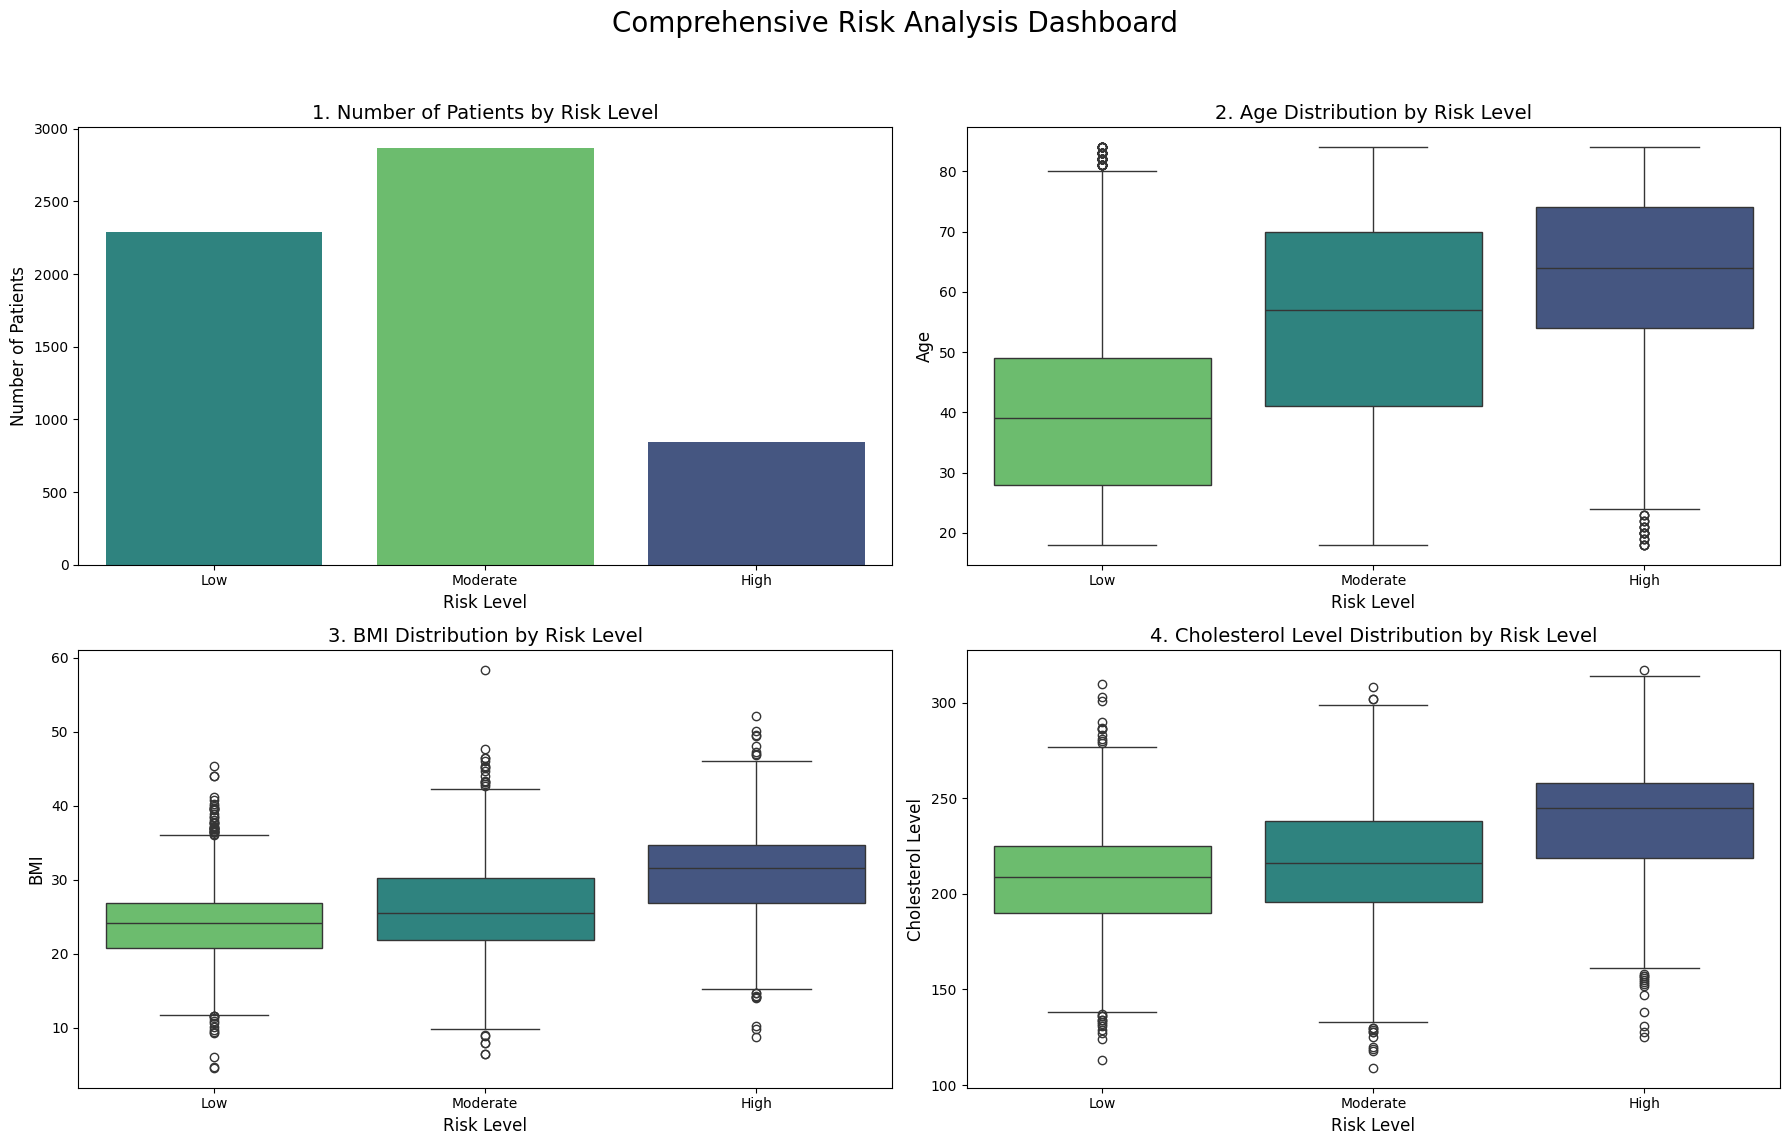

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Comprehensive Risk Analysis Dashboard', fontsize=20)

# Plot 1: Patient Count by Risk Level
sns.barplot(x='Risk_Level', y='Patient_Count', data=patient_counts_by_risk, order=risk_order, palette='viridis', hue='Risk_Level', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('1. Number of Patients by Risk Level', fontsize=14)
axes[0, 0].set_xlabel('Risk Level', fontsize=12)
axes[0, 0].set_ylabel('Number of Patients', fontsize=12)

# Plot 2: Distribution of Age by Risk Level
sns.boxplot(data=df, x='Risk_Level', y='Age', hue='Risk_Level', palette='viridis', order=risk_order, legend=False, ax=axes[0, 1])
axes[0, 1].set_title('2. Age Distribution by Risk Level', fontsize=14)
axes[0, 1].set_xlabel('Risk Level', fontsize=12)
axes[0, 1].set_ylabel('Age', fontsize=12)

# Plot 3: Distribution of BMI by Risk Level
sns.boxplot(data=df, x='Risk_Level', y='BMI', hue='Risk_Level', palette='viridis', order=risk_order, legend=False, ax=axes[1, 0])
axes[1, 0].set_title('3. BMI Distribution by Risk Level', fontsize=14)
axes[1, 0].set_xlabel('Risk Level', fontsize=12)
axes[1, 0].set_ylabel('BMI', fontsize=12)

# Plot 4: Distribution of Cholesterol Level by Risk Level
sns.boxplot(data=df, x='Risk_Level', y='Cholesterol_Level', hue='Risk_Level', palette='viridis', order=risk_order, legend=False, ax=axes[1, 1])
axes[1, 1].set_title('4. Cholesterol Level Distribution by Risk Level', fontsize=14)
axes[1, 1].set_xlabel('Risk Level', fontsize=12)
axes[1, 1].set_ylabel('Cholesterol Level', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Comprehensive Healthcare Risk Analysis Report

This report summarizes the key findings from the analysis of the healthcare risk dataset, providing insights into patient demographics, health indicators, lifestyle patterns, and their relationship with assigned risk levels.

---

#### 1. Data Overview and Preparation Highlights

*   **Dataset**: The analysis utilized the `healthcare_risk_analysis_dataset.xlsx` file.
*   **Missing Data Handling**: To ensure data quality, missing numerical values (like `BMI`, `Cholesterol_Level`, `Glucose_Level`, `Sleep_Hours`) were filled with their **medians**, while missing categorical values (`Alcohol_Consumption`, `Diagnosed_Condition`) were replaced with **'Unknown'**.
*   **Data Normalization**: The `Age` column was scaled to a range of 0 to 1, a common practice for preparing data for machine learning models.

---

#### 2. Key Exploratory Data Analysis (EDA) Findings

*   **Age and BMI Distributions**: Both `Age` and `BMI` showed varied distributions, with `BMI` generally displaying a somewhat normal distribution but with a tail towards higher values. `Age` represented a broad spectrum of adult patients.
*   **Age vs. BMI Relationship**: The scatter plot revealed a positive correlation, where `BMI` tends to increase with `Age`, particularly noticeable up to middle age, suggesting age as a contributing factor to BMI.
*   **Lifestyle Patterns**: The analysis explored common trends in `Smoking_Status`, `Alcohol_Consumption`, `Physical_Activity`, `Diet_Type`, `Sleep_Hours`, and `Stress_Level` within the patient population.
*   **Lifestyle vs. Risk Level**:
    *   Certain lifestyle factors showed clear associations with `Risk_Level`. For example, patients with 'Sedentary' physical activity and 'Unhealthy' diet types appeared more frequently in higher risk categories.
    *   `Sleep_Hours` and `Stress_Level` did not show statistically significant differences across risk levels in ANOVA, implying they might not be primary discriminators of risk in this dataset compared to other factors.

---

#### 3. Statistical Insights: ANOVA Results

One-way ANOVA was performed to identify health indicators with statistically significant differences across 'Low', 'Moderate', and 'High' `Risk_Level` groups.

*   **Significant Indicators (P-value < 0.05)**:
    *   `Age`
    *   `BMI`
    *   `Systolic_BP`
    *   `Diastolic_BP`
    *   `Cholesterol_Level`
    *   `Glucose_Level`
    
    These indicators show a strong association with a patient's risk level, with higher values generally observed in higher risk groups.

*   **Non-Significant Indicators (P-value > 0.05)**:
    *   `Sleep_Hours`
    *   `Stress_Level`
    
    The average values of these indicators do not differ significantly across risk levels.

*   **Correlation vs. Causation**: It's crucial to remember that these statistical associations do not imply direct causation. Other underlying factors may be at play.

---

#### 4. Patient Grouping and Actionable Insights

*   **Patient Counts**: The dataset contained more patients in the 'Moderate' risk category, followed by 'Low', and then 'High'.
*   **Average Health Indicators by Risk Level**:
    *   **Low Risk**: Younger patients with lower average BMI, blood pressure, cholesterol, and glucose levels.
    *   **Moderate Risk**: Intermediate values for age and health indicators, generally higher than 'Low' but lower than 'High'.
    *   **High Risk**: Older patients with higher average BMI, blood pressure (Systolic), cholesterol, and glucose levels.
*   **Top Diagnosed Conditions (Excluding 'Unknown')**:
    *   **Low Risk**: Diabetes, Hypertension, Asthma, Heart Disease.
    *   **Moderate Risk**: Hypertension, Diabetes, Asthma, Heart Disease.
    *   **High Risk**: Diabetes, Hypertension, Asthma, Heart Disease.
    
    Across all risk levels, Diabetes, Hypertension, Asthma, and Heart Disease are the most commonly diagnosed conditions, indicating their prevalence in the dataset and their potential role in defining risk.

---

#### 5. Visual Dashboard: Key Risk Insights

The dashboard consolidates these findings visually:

*   **Patient Count by Risk Level**: Confirms the distribution of patients across risk categories.
*   **Age, BMI, and Cholesterol Level Distributions by Risk Level**: Box plots visually reinforce the statistical findings, showing clear upward trends for these indicators as risk level increases (e.g., older patients and those with higher BMI/Cholesterol levels are predominantly in higher risk groups).

---

#### Conclusion

This analysis reveals that **Age, BMI, Blood Pressure (Systolic and Diastolic), Cholesterol Level, and Glucose Level** are significant indicators differentiating patient risk levels. Patients in higher risk categories tend to be older and exhibit less favorable health metrics across these indicators. While common conditions like Diabetes and Hypertension are prevalent across all groups, their manifestation and severity likely contribute to the assigned risk level. This report provides a foundational understanding of the dataset's characteristics and the primary factors influencing patient health risk.